<a href="https://colab.research.google.com/github/BrayanAQ/Analisis-del-estres-acad-mico-en-estudiantes-universitarios-de-Bangladesh-mediante-Python-en-el-2025/blob/main/Funciones_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from prettytable import PrettyTable


In [8]:
datos = pd.read_csv('/content/Stress Indicators Dataset for Mental Health Classification.csv')


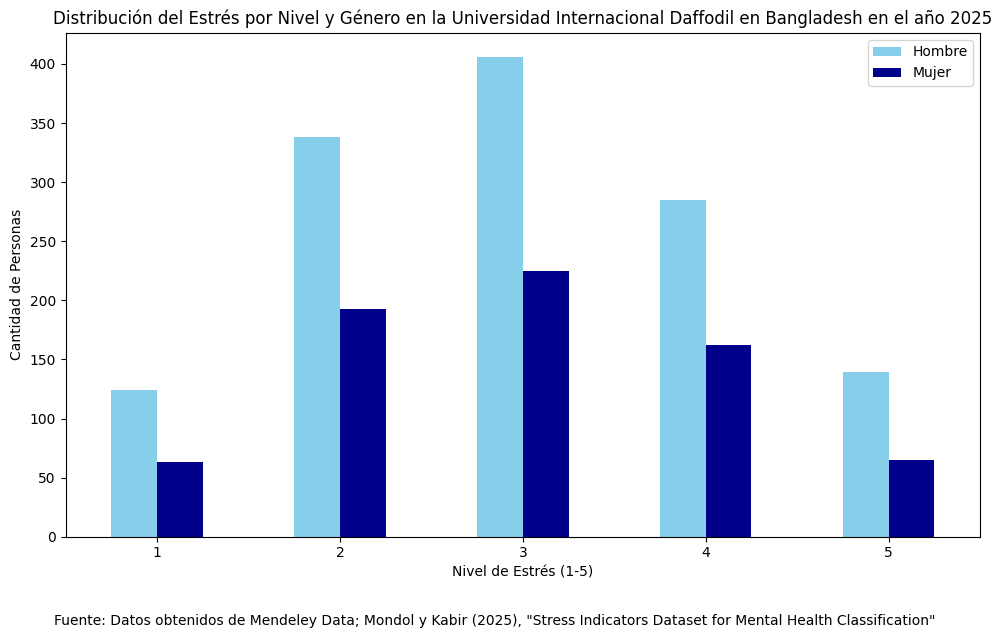

In [20]:
def EstresPorGenero(datos):

  nivel_genero = datos.groupby(['stress_experience', 'gender']).size().unstack(fill_value=0)


  nivel_genero = nivel_genero.sort_index()

  # Graficar
  nivel_genero.plot(
      kind='bar',
      figsize=(10, 6),
      color=['skyblue', 'darkblue']
  )

  plt.title('Distribución del Estrés por Nivel y Género en la Universidad Internacional Daffodil en Bangladesh en el año 2025')
  plt.xlabel('Nivel de Estrés (1-5)')
  plt.ylabel('Cantidad de Personas')
  plt.xticks(rotation=0)
  plt.legend(['Hombre', 'Mujer'])
  plt.tight_layout()
  plt.figtext(0.5, -0.05, 'Fuente: Datos obtenidos de Mendeley Data; Mondol y Kabir (2025), "Stress Indicators Dataset for Mental Health Classification"',
              ha='center', fontsize=10)

  plt.show()


EstresPorGenero(datos)




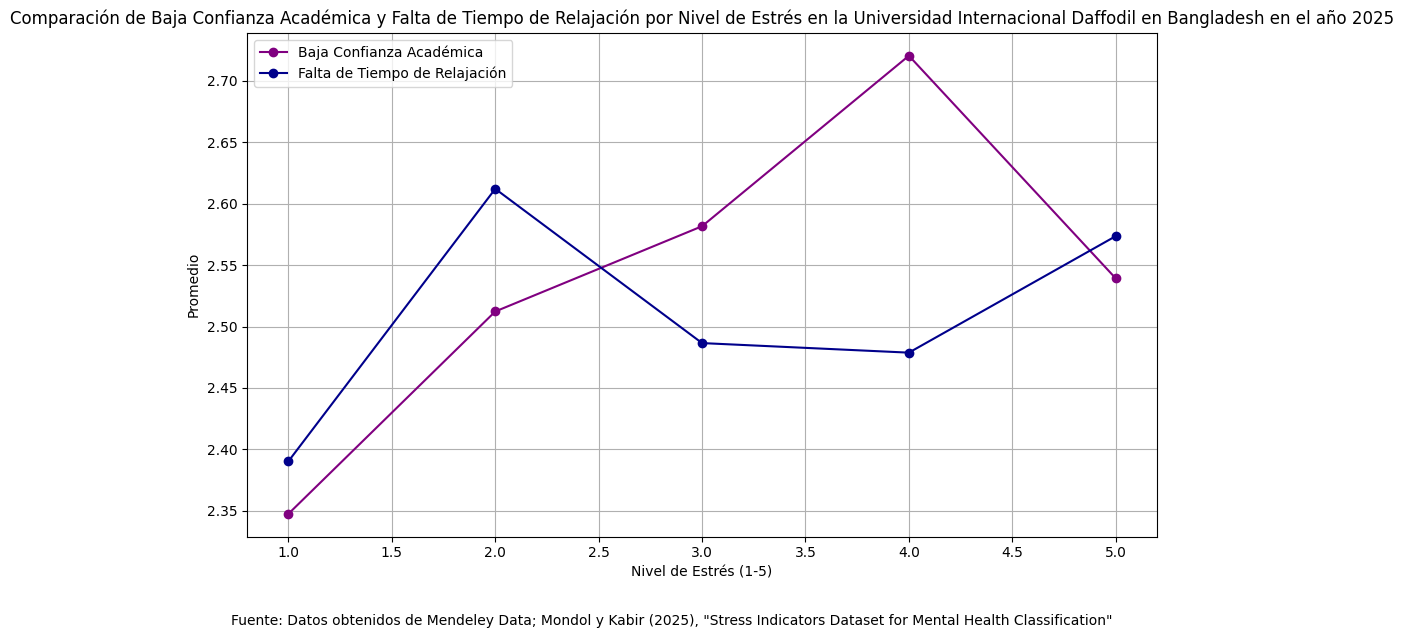

In [23]:
def Relacion_Rendimiento_BalanceVida(datos):
  # Calculate mean of low_academic_confidence and lack_relaxation_time for each stress_experience level
  avg_data = datos.groupby('stress_experience')[['low_academic_confidence', 'lack_relaxation_time']].mean()

  plt.figure(figsize=(10,6))
  plt.plot(avg_data.index, avg_data['low_academic_confidence'], marker='o', label='Baja Confianza Académica', color='purple')
  plt.plot(avg_data.index, avg_data['lack_relaxation_time'], marker='o', label='Falta de Tiempo de Relajación', color='darkblue')

  plt.title('Comparación de Baja Confianza Académica y Falta de Tiempo de Relajación por Nivel de Estrés en la Universidad Internacional Daffodil en Bangladesh en el año 2025')
  plt.xlabel('Nivel de Estrés (1-5)')
  plt.ylabel('Promedio')
  plt.legend()
  plt.grid()
  plt.tight_layout()
  plt.figtext(0.5, -0.05, 'Fuente: Datos obtenidos de Mendeley Data; Mondol y Kabir (2025), "Stress Indicators Dataset for Mental Health Classification"',
              ha='center', fontsize=10)

  plt.show()
Relacion_Rendimiento_BalanceVida(datos)

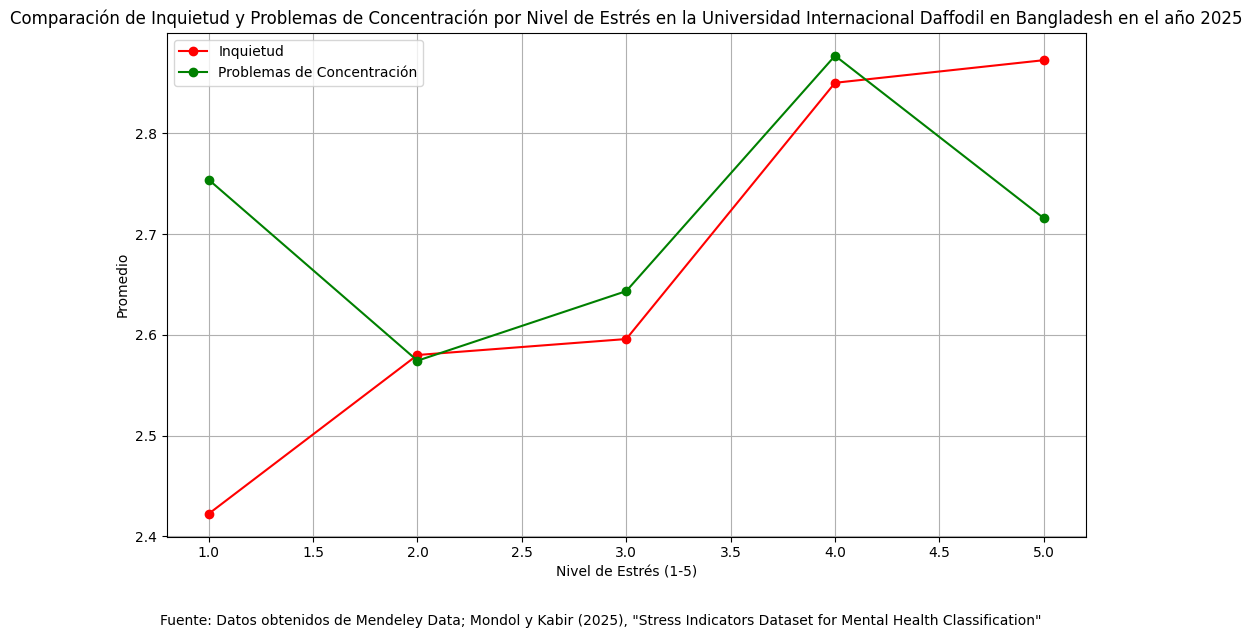

In [24]:


def Relacion_Fatiga_Concentracion(datos):
  # Calculate mean of restlessness and concentration_problems for each stress_experience level
  avg_data = datos.groupby('stress_experience')[['restlessness', 'concentration_problems']].mean()

  plt.figure(figsize=(10,6))
  plt.plot(avg_data.index, avg_data['restlessness'], marker='o', label='Inquietud', color='red')
  plt.plot(avg_data.index, avg_data['concentration_problems'], marker='o', label='Problemas de Concentración', color='green')

  plt.title('Comparación de Inquietud y Problemas de Concentración por Nivel de Estrés en la Universidad Internacional Daffodil en Bangladesh en el año 2025')
  plt.xlabel('Nivel de Estrés (1-5)')
  plt.ylabel('Promedio')
  plt.legend()
  plt.grid()
  plt.tight_layout()
  plt.figtext(0.5, -0.05, 'Fuente: Datos obtenidos de Mendeley Data; Mondol y Kabir (2025), "Stress Indicators Dataset for Mental Health Classification"',
            ha='center', fontsize=10)

  plt.show()
Relacion_Fatiga_Concentracion(datos)

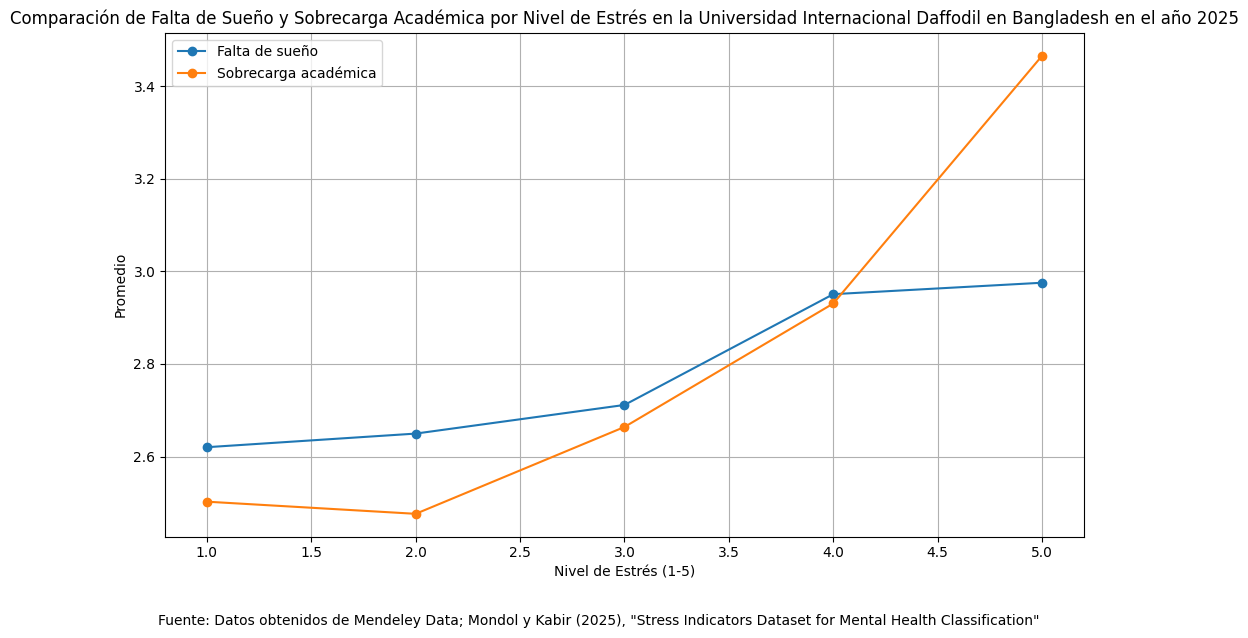

In [21]:

def Relacion_FaltasDeSueño_Sobrecarga(datos):

  faltas_genero = datos.groupby(['sleep_problems', 'gender']).size().unstack(fill_value=0)


  faltas_genero = faltas_genero.sort_index()
  line_data = datos.groupby('stress_experience')[['sleep_problems', 'academic_conflicts']].mean()

  # Graficar líneas
  plt.figure(figsize=(10,6))

  plt.plot(line_data.index, line_data['sleep_problems'], marker='o', label='Falta de sueño')
  plt.plot(line_data.index, line_data['academic_conflicts'], marker='o', label='Sobrecarga académica')

  plt.title('Comparación de Falta de Sueño y Sobrecarga Académica por Nivel de Estrés en la Universidad Internacional Daffodil en Bangladesh en el año 2025')
  plt.xlabel('Nivel de Estrés (1-5)')
  plt.ylabel('Promedio')
  plt.legend()
  plt.grid()
  plt.tight_layout()
  plt.figtext(0.5, -0.05, 'Fuente: Datos obtenidos de Mendeley Data; Mondol y Kabir (2025), "Stress Indicators Dataset for Mental Health Classification"',
              ha='center', fontsize=10)

  plt.show()
Relacion_FaltasDeSueño_Sobrecarga(datos)

In [15]:
import pandas as pd

def distribucion_riesgo(df, umbral=4):

    # Excluir columnas no indicadoras
    exclude_cols = ['gender', 'age', 'stress_type']
    indicator_cols = [col for col in df.columns if col not in exclude_cols]

    # Calcular puntaje de riesgo (sin modificar el DataFrame original)
    risk_score = (df[indicator_cols] >= umbral).sum(axis=1)

    # Obtener distribución
    total_personas = len(df)
    distribucion = risk_score.value_counts().sort_index()

    # Crear tabla
    print("\n" + "-"*60)
    print("        DISTRIBUCIÓN DE PUNTAJES DE RIESGO")
    print("En la Universional Internacional Daffodil en Bangladesh en el año 2025")
    print("-"*60)

    table = PrettyTable()
    table.field_names = ["Síntomas graves", "Personas", "Porcentaje", "Porcentaje acumulado"]
    table.align["Síntomas graves"] = "c"
    table.align["Personas"] = "r"
    table.align["Porcentaje"] = "r"
    table.align["Porcentaje acumulado"] = "r"

    acumulado = 0
    for score, count in distribucion.items():
        acumulado += count
        porcentaje = (count / total_personas) * 100
        porcentaje_acum = (acumulado / total_personas) * 100
        table.add_row([f"{score}", f"{count}", f"{porcentaje:.1f}%", f"{porcentaje_acum:.1f}%"])

    print(table)
    print("\n" + "="*60 + "\n")

    # Estadísticas adicionales útiles
    print(f"📊 Resumen rápido:")
    print(f"   • Personas con 0 síntomas graves: {distribucion.get(0, 0)}")
    print(f"   • Personas con ≥5 síntomas graves: {(risk_score >= 5).sum()}")
    print(f"   • Personas con ≥10 síntomas graves: {(risk_score >= 10).sum()}")

distribucion_riesgo(datos, umbral=4)




------------------------------------------------------------
        DISTRIBUCIÓN DE PUNTAJES DE RIESGO
En la Universional Internacional Daffodil en Bangladesh en el año 2025
------------------------------------------------------------
+-----------------+----------+------------+----------------------+
| Síntomas graves | Personas | Porcentaje | Porcentaje acumulado |
+-----------------+----------+------------+----------------------+
|        0        |       23 |       1.1% |                 1.1% |
|        1        |       81 |       4.0% |                 5.2% |
|        2        |      172 |       8.6% |                13.8% |
|        3        |      252 |      12.6% |                26.4% |
|        4        |      245 |      12.2% |                38.6% |
|        5        |      315 |      15.8% |                54.4% |
|        6        |      237 |      11.8% |                66.2% |
|        7        |      204 |      10.2% |                76.4% |
|        8        |      1

In [17]:
def analisis_estres_por_edad(datos, umbral_grave=4):
    """
    Analiza la gravedad del estrés comparando diferentes grupos de edad.
    """
    df = datos.copy()

    # Crear grupos de edad
    def grupo_edad(edad):
        if edad < 18:
            return 'Adolescente (<18)'
        elif edad <= 25:
            return 'Adulto joven (18-25)'
        elif edad <= 35:
            return 'Adulto (26-35)'
        else:
            return 'Adulto (36+)'

    df['grupo_edad'] = df['age'].apply(grupo_edad)

    # Orden de grupos
    orden_grupos = ['Adolescente (<18)', 'Adulto joven (18-25)', 'Adulto (26-35)', 'Adulto (36+)']

    print("\n" + "="*80)
    print("                     ANÁLISIS DE GRAVEDAD DE ESTRÉS POR EDAD")
    print("En la Universional Internacional Daffodil en Bangladesh en el año 2025")

    print("="*80)

    # Encabezados
    print(f"{'Grupo de edad':<20} {'Personas':>8} {'% Angustia':>12} {'% Eustrés':>11} {'% Mixto':>9}")
    print("-"*80)

    # Diccionario para guardar porcentajes de angustia
    angustia_por_grupo = {}

    for grupo in orden_grupos:
        if grupo in df['grupo_edad'].values:
            subset = df[df['grupo_edad'] == grupo]
            total = len(subset)

            pct_angustia = (subset['stress_type'] == 0).sum() / total * 100
            pct_eustres = (subset['stress_type'] == 1).sum() / total * 100
            pct_mixto = (subset['stress_type'] == 2).sum() / total * 100

            # Guardar para el resumen
            angustia_por_grupo[grupo] = pct_angustia

            print(f"{grupo:<20} {total:>8} {pct_angustia:>11.1f}% {pct_eustres:>10.1f}% {pct_mixto:>8.1f}%")

    print("="*80)

    # Resumen ejecutivo
    print("\n" + "-"*80)
    print("RESUMEN EJECUTIVO (ENFOQUE EN ANGUSTIA - ESTRÉS NEGATIVO):")
    print("-"*80)

    # Encontrar grupo con mayor y menor angustia
    grupo_max_angustia = max(angustia_por_grupo, key=angustia_por_grupo.get)
    max_angustia = angustia_por_grupo[grupo_max_angustia]

    grupo_min_angustia = min(angustia_por_grupo, key=angustia_por_grupo.get)
    min_angustia = angustia_por_grupo[grupo_min_angustia]

    print(f"⚠️  Grupo con MAYOR porcentaje de ANGUSTIA (estrés negativo): {grupo_max_angustia}")
    print(f"   → {max_angustia:.1f}% de este grupo tiene estrés negativo que requiere intervención")

    print(f"\n✓ Grupo con MENOR porcentaje de ANGUSTIA: {grupo_min_angustia}")
    print(f"   → {min_angustia:.1f}% de este grupo tiene estrés negativo")

    # Diferencia
    diferencia = max_angustia - min_angustia
    print(f"\n📊 Diferencia entre grupos: {diferencia:.1f} puntos porcentuales")

    print("="*80 + "\n")

    return None

analisis_estres_por_edad(datos, umbral_grave=4)




                     ANÁLISIS DE GRAVEDAD DE ESTRÉS POR EDAD
En la Universional Internacional Daffodil en Bangladesh en el año 2025
Grupo de edad        Personas   % Angustia   % Eustrés   % Mixto
--------------------------------------------------------------------------------
Adolescente (<18)          88         3.4%       85.2%     11.4%
Adulto joven (18-25)     1862         3.5%       91.7%      4.8%
Adulto (26-35)             21         0.0%      100.0%      0.0%
Adulto (36+)               29         6.9%       82.8%     10.3%

--------------------------------------------------------------------------------
RESUMEN EJECUTIVO (ENFOQUE EN ANGUSTIA - ESTRÉS NEGATIVO):
--------------------------------------------------------------------------------
⚠️  Grupo con MAYOR porcentaje de ANGUSTIA (estrés negativo): Adulto (36+)
   → 6.9% de este grupo tiene estrés negativo que requiere intervención

✓ Grupo con MENOR porcentaje de ANGUSTIA: Adulto (26-35)
   → 0.0% de este grupo tiene estr

In [18]:
def top_sintomas_graves(df, umbral, top_n):
    # Excluir columnas no indicadoras
    exclude_cols = ['gender', 'age', 'stress_type']
    indicator_cols = [col for col in df.columns if col not in exclude_cols]

    # Calcular frecuencia de síntomas graves
    total_personas = len(df)
    frecuencias = {}

    for col in indicator_cols:
        frecuencias[col] = (df[col] >= umbral).sum()

    # Ordenar y tomar top_n
    top_sintomas = sorted(frecuencias.items(), key=lambda x: x[1], reverse=True)[:top_n]

    # Crear tabla con print
    print("\n" + "-"*60)
    print(f"LOS {top_n} SÍNTOMAS GRAVES MÁS FRECUENTES (>= {umbral})")
    print("En la Universional Internacional Daffodil en Bangladesh en el año 2025")

    print("-"*60)

    # Encabezados
    print(f"{'#':^4} {'Síntoma':<35} {'Personas':>10} {'Porcentaje':>9}")
    print("-"*60)

    # Filas
    for i, (sintoma, count) in enumerate(top_sintomas, 1):
        porcentaje = (count / total_personas) * 100
        nombre_limpio = sintoma.replace('_', ' ').title()
        print(f"{i:^4} {nombre_limpio:<35} {count:>10} {porcentaje:>8.1f}%")

    print("-"*60)

    # Estadísticas adicionales
    print("\n" + "-"*40)
    print(f"📊 Datos complementarios:")
    print(f"   • Total de personas evaluadas: {total_personas}")
    print(f"   • Total de síntomas analizados: {len(indicator_cols)}")
    print(f"   • Síntoma más frecuente: {top_sintomas[0][0].replace('_', ' ').title()} ({top_sintomas[0][1]} personas)")

    # Mostrar si hay síntomas con 0 casos
    sintomas_cero = [s for s, c in frecuencias.items() if c == 0]
    if sintomas_cero:
        print(f"   • Síntomas sin casos graves: {len(sintomas_cero)}")

    print("="*60 + "\n")

    return top_sintomas

# Ejecutar
top_sintomas_graves(datos, umbral=4, top_n=5)






------------------------------------------------------------
LOS 5 SÍNTOMAS GRAVES MÁS FRECUENTES (>= 4)
En la Universional Internacional Daffodil en Bangladesh en el año 2025
------------------------------------------------------------
 #   Síntoma                               Personas Porcentaje
------------------------------------------------------------
 1   Class Attendance                           917     45.9%
 2   Stress Experience                          651     32.6%
 3   Sleep Problems                             590     29.5%
 4   Irritability                               587     29.3%
 5   Academic Conflicts                         581     29.0%
------------------------------------------------------------

----------------------------------------
📊 Datos complementarios:
   • Total de personas evaluadas: 2000
   • Total de síntomas analizados: 23
   • Síntoma más frecuente: Class Attendance (917 personas)



[('class_attendance', np.int64(917)),
 ('stress_experience', np.int64(651)),
 ('sleep_problems', np.int64(590)),
 ('irritability', np.int64(587)),
 ('academic_conflicts', np.int64(581))]

In [16]:
def riesgo_academico_por_tipo_estres(df, umbral=4):
    variables = [
        'academic_overload',
        'peer_competition',
        'low_academic_confidence',
        'academic_conflicts',
        'professor_difficulties'
    ]

    nombres_estres = {
        0: 'Distress',
        1: 'Eustress',
        2: 'Mixto/Otro'
    }

    tabla = PrettyTable()
    tabla.field_names = [
        "Tipo de estrés",
        "Total estudiantes",
        "Promedio riesgo académico",
        "Estudiantes en riesgo",
        "% en riesgo"
    ]

    df = df.copy()
    df['riesgo_academico'] = df[variables].mean(axis=1)
    df['en_riesgo'] = df['riesgo_academico'] >= umbral

    resumen = df.groupby('stress_type').agg(
        total=('stress_type', 'count'),
        promedio_riesgo=('riesgo_academico', 'mean'),
        estudiantes_riesgo=('en_riesgo', 'sum')
    )

    for tipo, fila in resumen.iterrows():
        porcentaje = (fila['estudiantes_riesgo'] / fila['total']) * 100

        tabla.add_row([
            nombres_estres.get(tipo, tipo),
            fila['total'],
            f"{fila['promedio_riesgo']:.2f}",
            fila['estudiantes_riesgo'],
            f"{porcentaje:.2f}%"
        ])

    print(tabla)

riesgo_academico_por_tipo_estres(datos)


+----------------+-------------------+---------------------------+-----------------------+-------------+
| Tipo de estrés | Total estudiantes | Promedio riesgo académico | Estudiantes en riesgo | % en riesgo |
+----------------+-------------------+---------------------------+-----------------------+-------------+
|    Distress    |        70.0       |            3.65           |          25.0         |    35.71%   |
|    Eustress    |       1828.0      |            2.55           |          42.0         |    2.30%    |
|   Mixto/Otro   |       102.0       |            1.78           |          0.0          |    0.00%    |
+----------------+-------------------+---------------------------+-----------------------+-------------+


In [19]:
def perfil_emocional_fisico_por_tipo_estres(df):
    emocionales = [
        'anxiety_tension',
        'sadness_low_mood',
        'loneliness_isolation',
        'irritability',
        'restlessness'
    ]

    fisicos = [
        'headaches',
        'health_issues',
        'weight_changes',
        'heartbeat_palpitations'
    ]

    nombres_estres = {
        0: 'Distress',
        1: 'Eustress',
        2: 'Mixto/Otro'
    }

    tabla = PrettyTable()
    tabla.field_names = [
        "Tipo de estrés",
        "Promedio emocional",
        "Promedio físico",
        "Dimensión dominante"
    ]

    df = df.copy()
    df['puntaje_emocional'] = df[emocionales].mean(axis=1)
    df['puntaje_fisico'] = df[fisicos].mean(axis=1)

    resumen = df.groupby('stress_type')[[
        'puntaje_emocional',
        'puntaje_fisico'
    ]].mean()

    for tipo, fila in resumen.iterrows():
        if fila['puntaje_emocional'] > fila['puntaje_fisico']:
            dominante = "Emocional"
        elif fila['puntaje_fisico'] > fila['puntaje_emocional']:
            dominante = "Físico"
        else:
            dominante = "Equilibrado"

        tabla.add_row([
            nombres_estres.get(tipo, tipo),
            f"{fila['puntaje_emocional']:.2f}",
            f"{fila['puntaje_fisico']:.2f}",
            dominante
        ])

    print(tabla)


perfil_emocional_fisico_por_tipo_estres(datos)

+----------------+--------------------+-----------------+---------------------+
| Tipo de estrés | Promedio emocional | Promedio físico | Dimensión dominante |
+----------------+--------------------+-----------------+---------------------+
|    Distress    |        4.01        |       3.89      |      Emocional      |
|    Eustress    |        2.59        |       2.57      |      Emocional      |
|   Mixto/Otro   |        1.72        |       1.76      |        Físico       |
+----------------+--------------------+-----------------+---------------------+


In [ ]:
def ranking_indicadores_por_tipo_estres(df, top_n=5):
    indicadores = [
        'stress_experience',
        'heartbeat_palpitations',
        'anxiety_tension',
        'sleep_problems',
        'restlessness',
        'irritability',
        'sadness_low_mood',
        'loneliness_isolation',
        'concentration_problems',
        'headaches',
        'health_issues',
        'weight_changes',
        'academic_overload',
        'peer_competition',
        'low_academic_confidence',
        'subject_confidence',
        'academic_conflicts',
        'class_attendance',
        'professor_difficulties',
        'work_environment',
        'home_environment',
        'relationship_stress',
        'lack_relaxation_time'
    ]

    nombres_estres = {
        0: 'Distress',
        1: 'Eustress',
        2: 'Mixto/Otro'
    }

    tabla = PrettyTable()
    tabla.field_names = [
        "Tipo de estrés",
        "Posición",
        "Indicador",
        "Promedio"
    ]

    resumen = df.groupby('stress_type')[indicadores].mean()

    for tipo, fila in resumen.iterrows():
        ranking = fila.sort_values(ascending=False).head(top_n)

        for posicion, (indicador, promedio) in enumerate(ranking.items(), start=1):
            tabla.add_row([
                nombres_estres.get(tipo, tipo),
                posicion,
                indicador,
                f"{promedio:.2f}"
            ])

    print(tabla)


ranking_indicadores_por_tipo_estres(datos, top_n=5)